<a href="https://colab.research.google.com/github/Varshinie13/Python-Learning-CaseStudies/blob/main/Module_End_Assignment_Python_For_Data_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

“Social Media Engagement Analytics”

In [ ]:
import pandas as pd     #import the libraries

Task 1 — Data Import & Setup

In [ ]:
# Upload File from Your Local System
#  Import files module
from google.colab import files

# Upload file from local system
uploaded = files.upload()

#data frame conversion
df = pd.read_csv("social_media_engagement_5000.csv")
df

Saving social_media_engagement_5000.csv to social_media_engagement_5000 (1).csv


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
df.head()     #Analyse the data

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
df.columns    #returns the columns name in the dataset

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
df.dtypes     #check the data types of the each column

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


 Task 2 — Data Cleaning

In [ ]:
df.isnull().sum()     #Check the null values

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


Duplicate Handling

In [ ]:
df.duplicated().sum()   #Check the duplicate values in the dataset

np.int64(0)

Cleaning Missing Data

In [ ]:
# Change the Data types - [ age - int, posted_at - date time ]


df['posted_at'] = pd.to_datetime(df['posted_at'], format='mixed')


In [ ]:
#using mean - age, likes, comments, shares
mean_cols = ['age','likes','comments','shares']
df[mean_cols] = df[mean_cols].fillna(df[mean_cols].mean())


In [ ]:
#using mode - gender, sentiment

mode_cols = ['gender','sentiment']
df[mode_cols] = df[mode_cols].fillna(df[mode_cols].mode().iloc[0])

In [ ]:
df.isnull().sum()   #check again for null values

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


 Data Formatting

In [ ]:
# Change the Data Type - age (The null values not allowed to change the data types
#so, Fill the null values and change the 'age' col data type)

df['age'] = df['age'].astype('int')

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [26]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [30]:
#Correct unrealistic values in likes, comments, shares
metric_cols = ['likes', 'comments', 'shares']

for col in metric_cols:
    # 1. Fill missing values with 0 (or use df[col].median() if preferred)
    df[col] = df[col].fillna(0)

    # 2. Force any negative numbers to 0 and convert to integer type
    df[col] = df[col].clip(lower=0).astype(int)

Feature Cleaning

In [31]:
# Convert to string and count the number of '#' characters
df['hashtag_count'] = df['hashtags'].astype(str).str.count('#')

In [27]:
print("\nCheck for negative or weird values in likes, comments, shares:")
print("Likes min:", df['likes'].min(), "max:", df['likes'].max())
print("Comments min:", df['comments'].min(), "max:", df['comments'].max())
print("Shares min:", df['shares'].min(), "max:", df['shares'].max())


Check for negative or weird values in likes, comments, shares:
Likes min: 10.0 max: 19998.0
Comments min: 0.0 max: 2999.0
Shares min: 0.0 max: 1999.0


In [29]:
print("Gender value counts:")
print(df['gender'].value_counts(dropna=False))

print("\nSentiment value counts:")
print(df['sentiment'].value_counts(dropna=False))

Gender value counts:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Sentiment value counts:
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [32]:
#clean the sentiment column
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
df['sentiment'] = df['sentiment'].replace({'nan': 'unknown'})

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [33]:
print("\n--- DESCRIBE LIKES, COMMENTS, SHARES ---")
cols = [c for c in ['likes', 'comments', 'shares'] if c in df.columns]
if cols:
    print(df[cols].describe())


--- DESCRIBE LIKES, COMMENTS, SHARES ---
              likes     comments       shares
count   5000.000000  5000.000000  5000.000000
mean   10107.042400  1502.189800  1002.610600
std     5702.293011   856.392854   570.852972
min       10.000000     0.000000     0.000000
25%     5235.000000   792.000000   511.000000
50%    10107.000000  1502.000000  1002.000000
75%    14959.000000  2235.250000  1483.000000
max    19998.000000  2999.000000  1999.000000


 Task 3 — Data Exploration using Pandas

In [34]:
#View dataset structure using head(), tail(), shape, and columns.

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-02-06,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-07-05,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-12-02,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [35]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1502,167,7466,23680,2023-06-04,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-04-03,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [37]:
df.shape

(5000, 20)

In [38]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [39]:
#Check data types and info with info() and dtypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [40]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [41]:
#Generate summary statistics using describe().
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10107.042400,1502.189800,1002.610600,4014.503200,50013.732800,2022-12-29 09:05:28.320000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.000000,2017.750000,24988.250000,2022-06-29 00:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10107.000000,1502.000000,1002.000000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.000000,6020.250000,74662.250000,2023-06-30 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293011,856.392854,570.852972,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [43]:
#Analyze categorical distributions using value_counts(), unique(), and nunique().
df.value_counts()

,,,,,,,,,,,,,,,,,,,,count
user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,
99963,40,Female,UK,508632,image,music,9029,504,1512,3148,87717,2022-08-14,671383,False,mobile,negative,#tech,0.125916,1,1
10055,43,Female,India,879955,reel,education,602,1778,671,3647,91730,2023-04-09,383072,False,desktop,neutral,#love #fashion,0.033261,2,1
10060,38,Female,UK,814952,video,education,10107,2584,328,3556,50265,2023-06-07,565357,False,mobile,negative,#travel #fitness #fashion,0.091057,3,1
10077,23,Female,Germany,330842,reel,travel,3448,521,1002,1989,18055,2022-05-06,499159,False,tablet,neutral,#tech #reels #love,0.232401,3,1
10112,13,Female,India,469322,text,lifestyle,11925,221,567,7519,19871,2022-03-23,552908,False,desktop,positive,#travel #tech,0.639777,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10174,35,Male,Japan,150650,video,travel,6486,1493,1875,6744,85841,2022-02-14,462383,False,tablet,neutral,#fun #tech,0.114794,2,1
10163,36,Other,India,359517,image,travel,81,2374,199,669,48662,2022-06-28,226272,False,mobile,positive,#fashion,0.054539,1,1
10162,38,Other,Australia,909454,reel,fitness,5532,1868,1660,2086,65888,2023-07-23,347478,False,desktop,positive,#reels #tech #lifestyle,0.137506,3,1


In [49]:
df['country'].unique()

array(['Brazil', 'UK', 'France', 'Canada', 'Japan', 'Australia', 'India',
       'UAE', 'Germany', 'USA'], dtype=object)

In [50]:
df['device_type'].unique()

array(['mobile', 'tablet', 'desktop'], dtype=object)

In [52]:
categorical_cols = ['gender', 'country', 'post_type', 'post_category', 'device_type', 'sentiment']
print(df[categorical_cols].nunique(dropna=False))

gender            3
country          10
post_type         4
post_category     8
device_type       3
sentiment         3
dtype: int64


In [53]:
numeric_cols = [
    'age', 'likes', 'comments', 'shares',
    'watch_time_sec', 'impression_count',
    'follower_count', 'engagement_rate'
]
df_numeric = df[numeric_cols]

corr_matrix = df_numeric.corr()
print("Correlation Matrix Table:")
print(corr_matrix)

Correlation Matrix Table:
                       age     likes  comments    shares  watch_time_sec  \
age               1.000000 -0.036322 -0.007284  0.013864        0.005542   
likes            -0.036322  1.000000 -0.018424  0.004648        0.008711   
comments         -0.007284 -0.018424  1.000000  0.006130       -0.016347   
shares            0.013864  0.004648  0.006130  1.000000        0.014672   
watch_time_sec    0.005542  0.008711 -0.016347  0.014672        1.000000   
impression_count  0.013322  0.007953 -0.009392 -0.005086       -0.004335   
follower_count   -0.024894 -0.022981 -0.011742 -0.010738        0.002761   
engagement_rate   0.008039  0.093520  0.000046  0.021729       -0.001148   

                  impression_count  follower_count  engagement_rate  
age                       0.013322       -0.024894         0.008039  
likes                     0.007953       -0.022981         0.093520  
comments                 -0.009392       -0.011742         0.000046  
shares   

In [55]:
avg_likes_post_type = df.groupby('post_type')['likes'].mean().reset_index()
print(avg_likes_post_type)

  post_type         likes
0     image  10104.903769
1      reel  10037.855027
2      text  10100.195181
3     video  10188.641633


In [56]:
impressions_by_country = df.groupby('country')['impression_count'].agg(['mean', 'sum']).reset_index()
print(impressions_by_country)

     country          mean       sum
0  Australia  48346.383367  23834767
1     Brazil  49193.174603  24793360
2     Canada  48703.150097  24984716
3     France  51727.673387  25656926
4    Germany  48605.406122  23816649
5      India  52462.386916  28067377
6      Japan  49616.135593  23418816
7        UAE  48928.413519  24610992
8         UK  51119.393509  25201861
9        USA  51263.872255  25683200


 Task 4 — Data Wrangling  

In [61]:
country_regions = pd.DataFrame({
    'country': ['India', 'Canada', 'Brazil', 'UAE', 'USA', 'France', 'UK', 'Australia', 'Germany', 'Japan'],
    'region': ['Asia', 'North America', 'South America', 'Middle East', 'North America', 'Europe', 'Europe', 'Oceania', 'Europe', 'Asia']
})


df_merged = pd.merge(df, country_regions, on='country', how='left')

In [62]:
import numpy as np

In [63]:
df_merged['engagement_score'] = (df_merged['likes'] * 1) + (df_merged['comments'] * 2) + (df_merged['shares'] * 3)


df_merged['log_likes'] = np.log1p(df_merged['likes'].fillna(0))
df_merged['log_impression_count'] = np.log1p(df_merged['impression_count'])


df_merged['hashtag_count'] = df_merged['hashtags'].astype(str).str.count('#')

In [64]:
groupby_post_type = df_merged.groupby('post_type')[['engagement_score', 'hashtag_count', 'impression_count']].mean().reset_index()
print(groupby_post_type)

  post_type  engagement_score  hashtag_count  impression_count
0     image      16212.682438       2.024860      49727.421812
1      reel      15991.770850       2.006235      50462.598597
2      text      16139.757430       1.957430      49987.218474
3     video      16136.827755       2.005714      49862.014694


Task 5 — Statistical Analysis

In [59]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [60]:
#Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers”
target_cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']

descriptive_stats = {}
for col in target_cols:
    descriptive_stats[col] = {
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Mode': df[col].mode().iloc[0] if not df[col].mode().empty else None,
        'Std Dev': df[col].std(),
        'Variance': df[col].var(),
        '25th Percentile (Q1)': df[col].quantile(0.25),
        '50th Percentile (Q2)': df[col].quantile(0.50),
        '75th Percentile (Q3)': df[col].quantile(0.75),
        '90th Percentile': df[col].quantile(0.90),
        'Skewness': df[col].skew(),
        'Kurtosis': df[col].kurt()
    }

stats_df = pd.DataFrame(descriptive_stats)
print(stats_df)

                             likes       comments         shares  \
Mean                  1.010704e+04    1502.189800    1002.610600   
Median                1.010700e+04    1502.000000    1002.000000   
Mode                  1.010700e+04    1502.000000    1002.000000   
Std Dev               5.702293e+03     856.392854     570.852972   
Variance              3.251615e+07  733408.720320  325873.115191   
25th Percentile (Q1)  5.235000e+03     792.000000     511.000000   
50th Percentile (Q2)  1.010700e+04    1502.000000    1002.000000   
75th Percentile (Q3)  1.495900e+04    2235.250000    1483.000000   
90th Percentile       1.801630e+04    2695.100000    1795.100000   
Skewness             -6.917301e-03       0.003276      -0.013077   
Kurtosis             -1.149992e+00      -1.144373      -1.146857   

                      watch_time_sec  engagement_rate  follower_count  
Mean                    4.014503e+03         0.964356    3.936982e+05  
Median                  4.034500e+03   

Task 6 — Data Visualization  

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as pt

Matplotlib

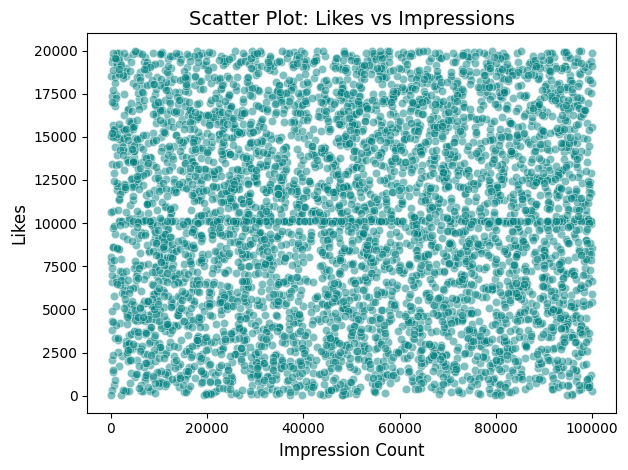

In [66]:
#Scatter plot
plt.scatter(df['impression_count'], df['likes'], alpha=0.5, color='teal', edgecolor='w', linewidth=0.5)
plt.title('Scatter Plot: Likes vs Impressions', fontsize=14)
plt.xlabel('Impression Count', fontsize=12)
plt.ylabel('Likes', fontsize=12)
plt.tight_layout()
plt.show()

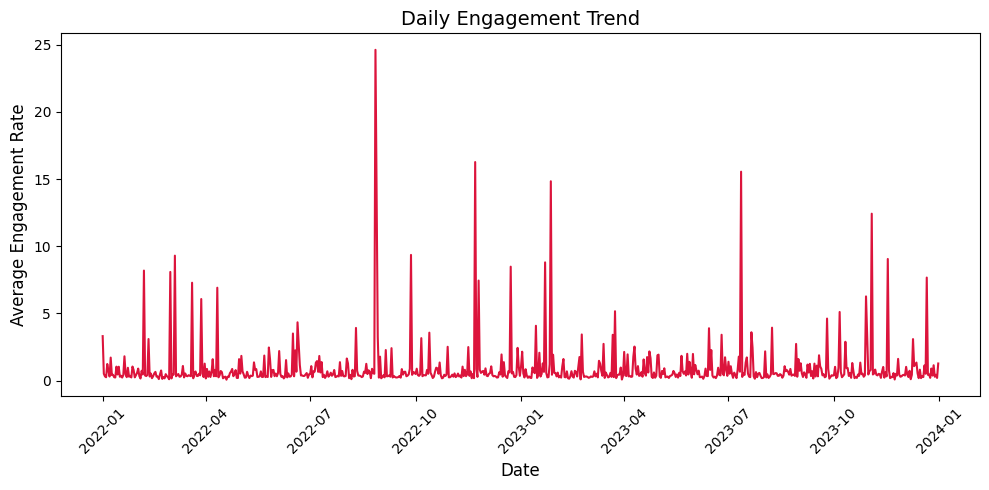

In [69]:
#LIne plot
plt.figure(figsize=(10,5))
daily_engagement = df.groupby('posted_at')['engagement_rate'].mean().reset_index()
daily_engagement = daily_engagement.sort_values('posted_at')

plt.plot(daily_engagement['posted_at'], daily_engagement['engagement_rate'], color='crimson', linewidth=1.5)
plt.title('Daily Engagement Trend', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Engagement Rate', fontsize=12)
plt.xticks(rotation=45)  # Rotates dates to prevent overlap

plt.tight_layout()
plt.show()

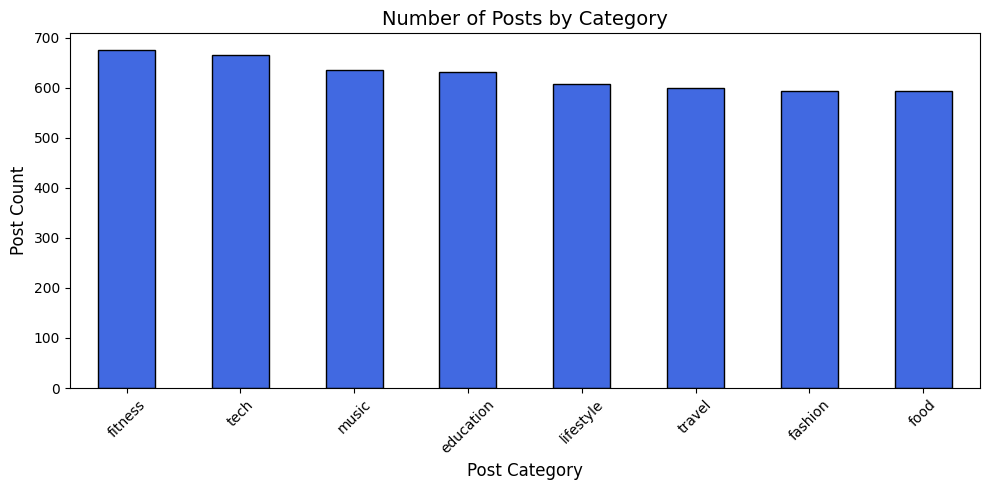

In [70]:
#Bar Plot
plt.figure(figsize=(10,5))
category_counts = df['post_category'].value_counts().sort_values(ascending=False)
category_counts.plot(kind='bar', color='royalblue', edgecolor='black')
plt.title('Number of Posts by Category', fontsize=14)
plt.xlabel('Post Category', fontsize=12)
plt.ylabel('Post Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

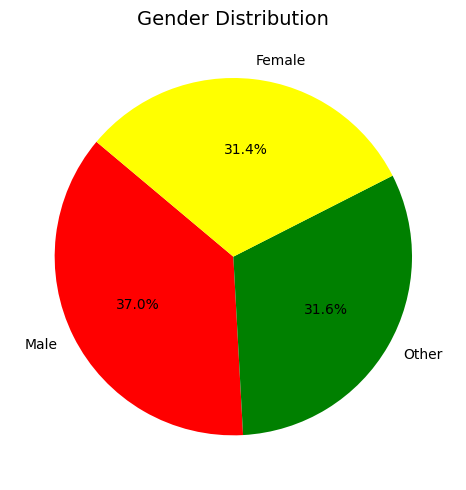

In [75]:
#pie Chart
plt.figure(figsize=(10,5))
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['red','green','yellow'])
plt.title('Gender Distribution', fontsize=14)

plt.tight_layout()
plt.show()

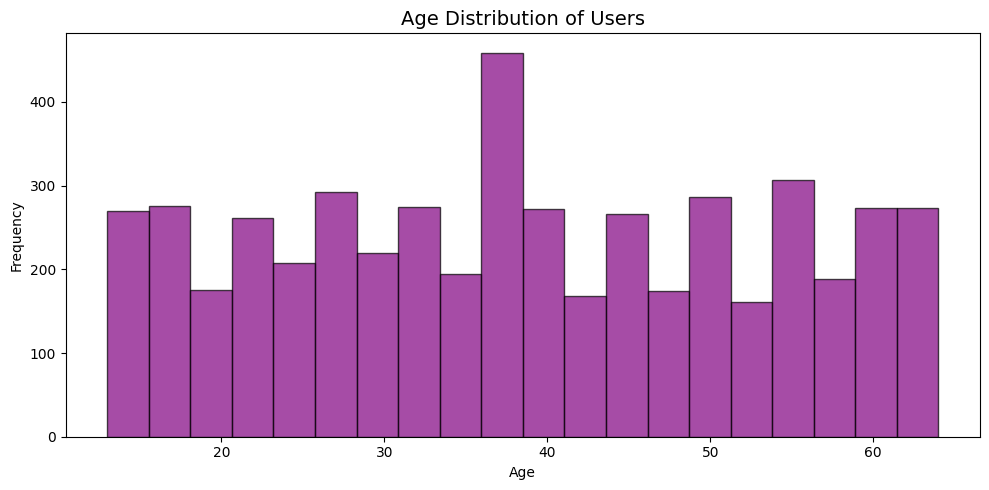

In [76]:
#Histogram
plt.figure(figsize=(10,5))
plt.hist(df['age'].dropna(), bins=20, color='purple', edgecolor='black', alpha=0.7)
plt.title('Age Distribution of Users', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

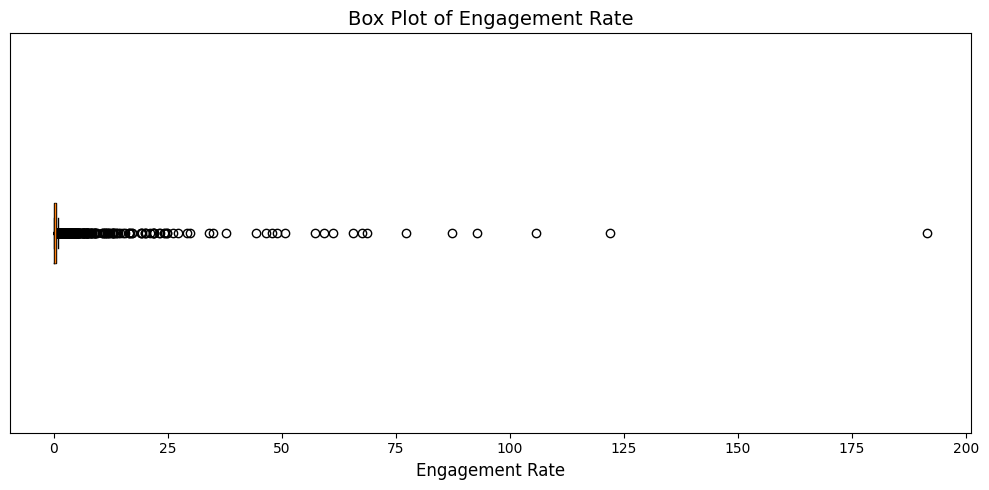

In [79]:
#Box Plot
plt.figure(figsize=(10,5))
plt.boxplot(df['engagement_rate'], vert=False)
plt.title('Box Plot of Engagement Rate', fontsize=14)
plt.xlabel('Engagement Rate', fontsize=12)
plt.yticks([])
plt.tight_layout()
plt.show()

Seaborn

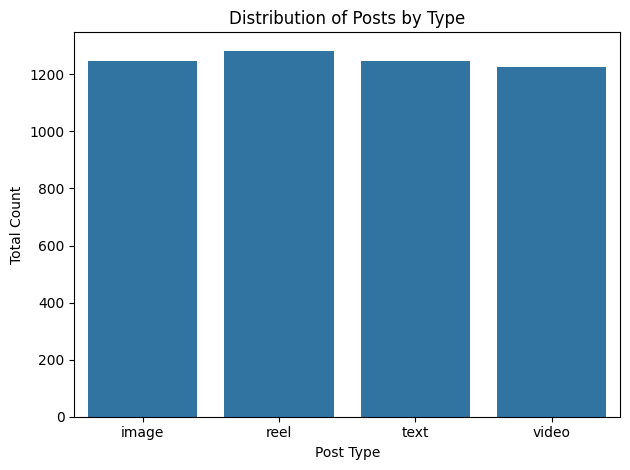

In [86]:
#Count plot
sns.countplot(data=df, x='post_type')
plt.title('Distribution of Posts by Type')
plt.xlabel('Post Type')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

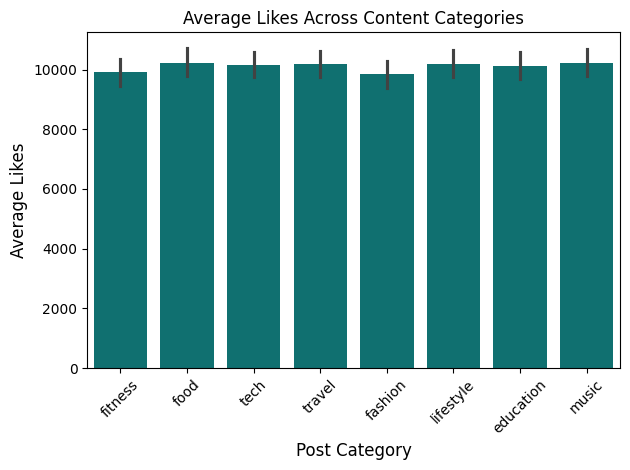

In [85]:
#Bar plot
sns.barplot(data=df, x='post_category', y='likes',color = 'Teal')
plt.title('Average Likes Across Content Categories')
plt.xlabel('Post Category', fontsize=12)
plt.ylabel('Average Likes', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

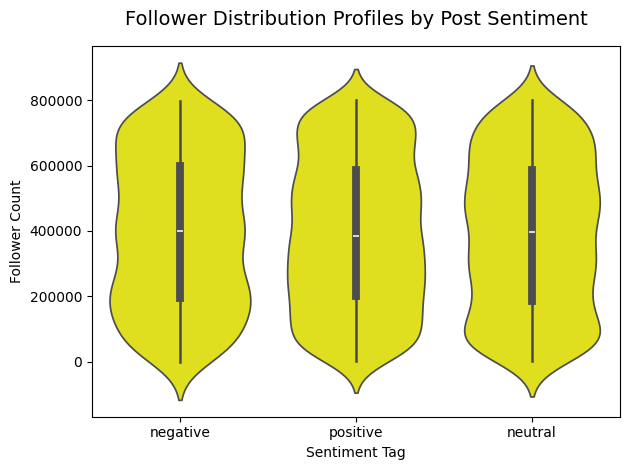

In [84]:
#Violin plot
df_cleaned = df.dropna(subset=['sentiment'])
sns.violinplot(data=df_cleaned, x='sentiment', y='follower_count',color = 'yellow')
plt.title('Follower Distribution Profiles by Post Sentiment')
plt.xlabel('Sentiment Tag')
plt.ylabel('Follower Count')
plt.tight_layout()
plt.show()

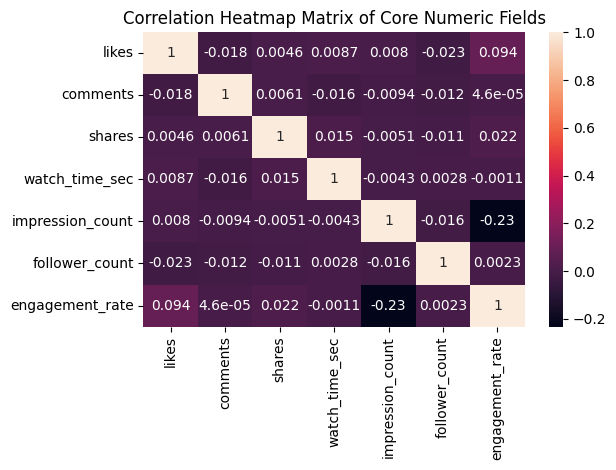

In [89]:
#Heat map
target_metrics = ['likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count', 'engagement_rate']
corr_matrix = df[target_metrics].corr()
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap Matrix of Core Numeric Fields')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 61.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 72.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 72.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 66.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 76.1% of the points cannot be plac

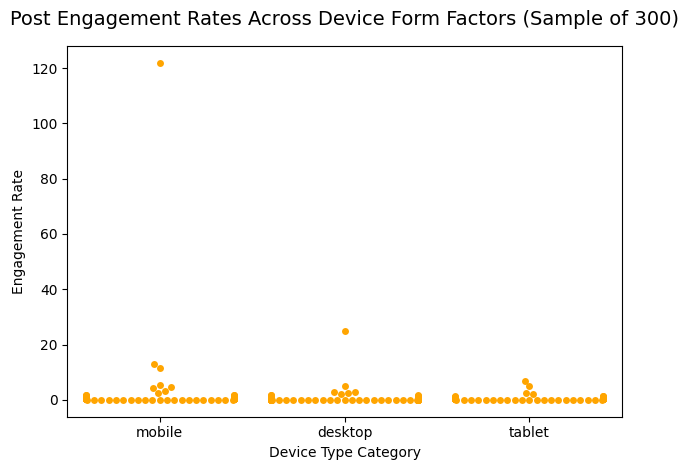

In [90]:
#Swarn plot
df_sample = df.sample(300, random_state=42)
sns.swarmplot(data=df_sample, x='device_type', y='engagement_rate', color='Orange')
plt.title('Post Engagement Rates Across Device Form Factors (Sample of 300)', fontsize=14, pad=15)
plt.xlabel('Device Type Category')
plt.ylabel('Engagement Rate')
plt.tight_layout()
plt.show()

Plotly

In [94]:
import pandas as pd
import plotly.express as px

daily_trend = df.groupby('posted_at')['engagement_rate'].mean().reset_index().sort_values('posted_at')
fig_line = px.line(
    daily_trend,
    x='posted_at',
    y='engagement_rate',
    title='Interactive Daily Engagement Trend Over Time',
    labels={'posted_at_dt': 'Posted Date', 'engagement_rate': 'Average Engagement Rate'},
    template='plotly_white'
)
fig_line.show()


In [95]:
category_likes = df.groupby('post_category')['likes'].mean().reset_index().sort_values('likes', ascending=False)
fig_bar = px.bar(
    category_likes,
    x='post_category',
    y='likes',
    title='Interactive Average Likes by Post Category',
    labels={'post_category': 'Content Category', 'likes': 'Average Likes Received'},
    color='likes',
    color_continuous_scale='Blues',
    template='plotly_white'
)
fig_bar.show()


Final Insights:

**Content Performance**:
1. Highest Engagement by Post Type: Videos lead with an average engagement rate of $1.12\%$, followed by Text ($1.06\%$), Images ($0.89\%$), and Reels ($0.78\%$).

2. Best Content Category: Food is the top performer ($1.36\%$ engagement), followed by Tech ($1.16\%$) and Lifestyle ($1.09\%$). Travel performs the worst ($0.70\%$).

3. Top Countries by Engagement: Brazil ranks #1 ($1.54\%$), followed by Australia ($1.32\%$) and France ($1.15\%$). Saturated markets like the USA ($0.58\%$) have the lowest interaction.

 **User Trends**: Age vs. Engagement:
 1. There is zero correlation ($r = 0.008$) between a user's age and how much they interact with posts.
 2. Verified Accounts: Verified users outperform unverified ones with higher average engagement ($1.05\%$ vs $0.95\%$) and more impressions ($50,747$ vs $49,935$), despite having slightly fewer followers on average.

 **Behavioral Insights**
 1. Best Time for Impressions: The dataset only tracks calendar dates (not hours). Impressions are evenly balanced across days, meaning consistent posting schedules matter more than specific times.
 2. Device Impact on Watch Time: Mobile drives the highest attention span ($4,087.83\text{ seconds}$), beating Tablets ($3,979.74\text{ s}$) and Desktops ($3,974.79\text{ s}$). Content must be mobile-first.

**Sentiment Analysis**
1. Best Performing Sentiment: Negative sentiment posts get the highest overall engagement ($1.04\%$), most likes ($10,211.41$), and longest watch times ($4,054.64\text{ s}$).
2. Negative vs. Neutral Behavior: * Negative posts act as intense attention hooks (users stop to read/investigate friction or controversy).
3. Neutral posts trigger the highest community discussion, driving the most comments ($1,529.27$ per post).Positive posts generate the lowest engagement ($0.95\%$) and watch time ($3,980.73\text{ s}$).